# 🔬 7.1 Explicabilidad (XAI) a Nivel de Residuo — BiLSTM_Small (Mean Pooling + AAontology)

Este notebook implementa el pipeline completo de **interpretabilidad** para el modelo `BiLSTM_Small` (Mean Pooling + AAontology), seleccionado como la mejor estrategia en el test externo según el MCC:

> Rendimiento en test: `Acc = 0.9178` · `F1 = 0.8709` · `MCC = 0.8108` · `AUC = 0.9571` · `PR‑AUC = 0.9354`

El objetivo es explicar **qué residuos** impulsan la predicción del modelo, tanto desde su dinámica interna como con métodos post‑hoc.

---

## 📋 Descripción general

El modelo `AAontologyBiLSTMClassifier` procesa tres entradas:

- `X`: embeddings por residuo de ProtFlash, `(B, L, 768)`.
- `Ont`: perfiles AAontology por residuo, `(B, L, 8)`.
- `M`: máscara binaria, `(B, L)`.

El pipeline de explicabilidad se articula en tres niveles:
1. **Importancia interna por residuo:** la arquitectura no incorpora un `GatedPooler`, por lo que la relevancia de cada posición se extrae mediante un *forward hook* sobre `model.lstm`, usando la norma‑L2 de los estados ocultos bidireccionales enmascarados por la longitud real (`M`).
2. **Explicaciones post‑hoc:** se aplican dos técnicas complementarias:
   - **Integrated Gradients (IG)** con línea base nula y 100 pasos de integración.
   - **KernelSHAP** con enmascaramiento de residuos y un background basado en la máscara cero.
3. **Validación biológica sobre LL‑37:** se contrasta la importancia atribuida a la región funcional del péptido antimicrobiano LL‑37 frente al conocimiento biológico esperado.

---

## 🛠️ Funcionalidades principales

1. **Importancia interna (hook sobre LSTM)**
   - Extracción de los estados ocultos bidireccionales por residuo.
   - Cálculo de la norma‑L2 enmascarada como señal de relevancia.

2. **Métodos post‑hoc**
   - Integrated Gradients con baseline nulo y 100 pasos.
   - KernelSHAP con enmascaramiento posicional y background de máscara cero.

3. **Agregación y consistencia**
   - Comparación de los mapas de importancia entre métodos.
   - Evaluación de concordancia (interna vs. post‑hoc).

4. **Validación biológica**
   - Estudio de caso sobre LL‑37.
   - Verificación de que los residuos destacados coincidan con el sitio funcional conocido.

# 📦 Instalación de Dependencias

In [1]:
!pip install shap captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 23.9 MB/s eta 0:00:00


# 🔧 Configuración e Importaciones

In [2]:
import os, json, warnings, ast
from pathlib import Path
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, mannwhitneyu

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import random
import shap
from captum.attr import IntegratedGradients
from captum.attr import visualization as captum_viz

warnings.filterwarnings("ignore")
torch.set_grad_enabled(True)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

torch: 2.10.0+cu128 | cuda: True


In [3]:
# ======= PATHS =======
CKPT_PATH       = Path("/kaggle/input/notebooks/user/otro-mean-pooling-aaontology-model-lstm/best_model_final.pth")
TEST_PT_PATH    = Path("/kaggle/input/datasets/user/new-final-dataset/test_dataset.pt")
AAONTOLOGY_PATH = Path("/kaggle/input/datasets/user/new-aaontology/AAontology_zscored.pt")

XAI_DIR         = Path("/kaggle/working/")
XAI_DIR.mkdir(parents=True, exist_ok=True)

# ======= CONSTANTES =======
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROT_EMBED_DIM = 768
SEED           = 31
THRESHOLD      = 0.5
N_BINS         = 50       # bins para posición relativa
BATCH_SIZE  = 32

# Subconjuntos para análisis 
N_SHAP_BG      = 5000   # muestras de background para KernelSHAP
N_SHAP_EXPLAIN = 500   # muestras a explicar con SHAP
N_IG_SAMPLES   = 500   # muestras para Integrated Gradients

IG_STEPS       = 100     # Pasos para la aproximación de la integral
IG_BATCH       = 64     # Batch size interno de Captum

SHAP_BG_SUMMARY_K       = 10    # nº de centroides tras resumir el pool de background (k-means)
SHAP_NSAMPLES_GLOBAL    = 100   # presupuesto por secuencia en el análisis global (1000 secuencias)
SHAP_NSAMPLES_CASE_STUDY = 5000  # mayor precisión para el caso de estudio LL-37 (1 sola secuencia)

AA_CANONICAL = list("ACDEFGHIKLMNPQRSTVWY")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 🧬 Carga del Tensor Fisicoquímico (AAontology)


In [4]:
# Carga el tensor (20, 8) precomputado con z-scores por categoría
if Path(AAONTOLOGY_PATH).exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]       # (21, 8)
    AA_ORDER = aa_data["amino_acids"]            # ['A', ..., 'Y', 'X']
    USED_CATEGORIES = aa_data["categories"]      # 8 categorías
else:
    raise FileNotFoundError(f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero.")

AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_CAT = AAONTOLOGY_ZSCORED.shape[1]

print(f"AAontology tensor: {AAONTOLOGY_ZSCORED.shape}")
print(f"Categorías: {USED_CATEGORIES}")

AAontology tensor: torch.Size([21, 8])
Categorías: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


In [5]:
BASELINE_X   = torch.zeros(PROT_EMBED_DIM)
BASELINE_ONT = torch.zeros(N_CAT)

## 📂 Definición de la clase `AMPDataset`

In [6]:
class AMPDataset(Dataset):
    """
    Estructura por muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings
        G:   torch.FloatTensor (L_max, 8)    — AAontology features
        M:   torch.FloatTensor (L_max,)      — binary mask
        seq: str                             — AA sequence (for AAontology)
        y:   torch.FloatTensor (1,)          — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, L_max, 768)
        self.G = torch.from_numpy(G).float()          # (N, L_max, 8)
        assert self.G.shape[-1] == 8, f"Se esperaban 8 categorías de ontología, pero G tiene shape {self.G.shape}"
        self.M = torch.from_numpy(M).float()          # (N, L_max)
        self.sequences = list(sequences)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.sequences) == len(self.y), \
            "Las longitudes de X, G, M, seqs y y no coinciden."

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (L_max, 768)
            "G": self.G[idx],           # (L_max, 8)
            "M": self.M[idx],           # (L_max,)
            "seq": self.sequences[idx],      # str (Ej: "MKLL...")
            "y": self.y[idx]            # (1,)
        }

## 🔑 Función para construir perfiles AAontology por batch

In [7]:
def build_ontology_profiles(seqs, B, L, dtype=torch.float32):
    """
    Construye Ont: (B, L, N_CAT) a partir de secuencias.
    Usa la fila 'X' para padding / aminoácidos desconocidos.
    """
    x_idx = AA_TO_IDX.get("X", AAONTOLOGY_ZSCORED.shape[0] - 1)

    aa_indices = torch.full((B, L), x_idx, dtype=torch.long)

    for i, seq in enumerate(seqs):
        if not seq:
            continue

        for j, aa in enumerate(seq[:L]):
            aa_indices[i, j] = AA_TO_IDX.get(aa, x_idx)

    return AAONTOLOGY_ZSCORED[aa_indices].to(dtype=dtype)

## 💾 Función de carga de datasets pre-serializados

In [8]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists():
        raise FileNotFoundError(pt_path)
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de prueba

In [9]:
print("Loading test dataset:")
test_ds = load_pt_dataset(TEST_PT_PATH)

pos = int(test_ds.y.sum().item())
neg = test_ds.y.shape[0] - pos
total = test_ds.y.shape[0]
print(f"Test set: total={len(test_ds.y)}, pos={pos}, neg={neg}, pos_ratio={pos/len(test_ds.y):.3f}")

Loading test dataset:
Test set: total=15685, pos=4914, neg=10771, pos_ratio=0.313


## 🤝 Función de colación (`collate_fn`)

In [10]:
def collate_fn_aaontology(batch):
    """
    Devuelve:
      X:   (B, L, 768)
      Ont: (B, L, 8)
      M:   (B, L)
      seqs: List[str]
      y:   (B, 1)
    """

    X = torch.stack([item["X"] for item in batch], dim=0)
    M = torch.stack([item["M"] for item in batch], dim=0)
    y = torch.stack([item["y"] for item in batch], dim=0)

    seqs = [item.get("seq", "") for item in batch]

    first = batch[0]

    # Caso 1: el dataset ya trae Ont precomputado.
    if "Ont" in first and first["Ont"] is not None:
        Ont = torch.stack([item["Ont"] for item in batch], dim=0).to(X.dtype)

    # Caso 2: el dataset trae G como ontología por residuo (B/L, 8).
    elif (
        "G" in first
        and isinstance(first["G"], torch.Tensor)
        and first["G"].dim() == 2
        and first["G"].size(-1) == N_CAT
    ):
        Ont = torch.stack([item["G"] for item in batch], dim=0).to(X.dtype)

    # Caso 3: construir Ont desde la secuencia.
    else:
        B, L, _ = X.shape
        Ont = build_ontology_profiles(seqs, B, L, dtype=X.dtype)

    return X, Ont, M, seqs, y

## 🚚 Creación de DataLoaders

In [11]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_aaontology)

print(f"✅ Dataset listo: {len(test_ds)} muestras")
print(f"   Ejemplo de batch: {[t.shape if isinstance(t, torch.Tensor) else type(t).__name__ for t in test_ds[0]]}")

# Comprobación
X_b, Ont_b, M_b, seq_b, y_b = next(iter(test_loader))

print("X:", X_b.shape)     # (B, L, 768)
print("Ont:", Ont_b.shape) # (B, L, 8)
print("M:", M_b.shape)     #

✅ Dataset listo: 15685 muestras
   Ejemplo de batch: ['str', 'str', 'str', 'str', 'str']
X: torch.Size([32, 100, 768])
Ont: torch.Size([32, 100, 8])
M: torch.Size([32, 100])


In [12]:
X_all, Ont_all, M_all, seqs_all, y_all = [], [], [], [], []
for X, Ont, M, seqs, y in test_loader:
    X_all.append(X); Ont_all.append(Ont); M_all.append(M)
    seqs_all.extend(seqs); y_all.append(y)

X_all, Ont_all, M_all = torch.cat(X_all), torch.cat(Ont_all), torch.cat(M_all)
y_all = torch.cat(y_all).squeeze(-1).long()
seq_lengths = M_all.sum(1).long().numpy()
L_max = X_all.shape[1]

## 🔑 Mecanismo `MaskedMeanPooler`

In [13]:
def masked_mean(X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    """
    X: (B, L, D)
    M: (B, L)

    Return:
      (B, D)
    """
    mask = M.unsqueeze(-1)  # (B, L, 1)
    summed = (X * mask).sum(dim=1)
    counts = M.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return summed / counts

## 🔑 Mecanismo AAontologyMeanPooler

In [14]:
class AAontologyMeanPooler(nn.Module):
    """
    Mean Pooling con AAontology.

    Input:
      X:   (B, L, input_dim)
      Ont: (B, L, n_categories)
      M:   (B, L)

    Output:
      E_local: (B, input_dim)
    """

    def __init__(
        self,
        input_dim: int = 768,
        n_categories: int = 8,
        ont_hidden: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.ont_proj = nn.Linear(n_categories, ont_hidden)

        self.fusion = nn.Sequential(
            nn.Linear(input_dim + ont_hidden, input_dim),
            nn.LayerNorm(input_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def transform_sequence(self, X, Ont, M):
        """
        Devuelve la secuencia fusionada:
          H: (B, L, input_dim)
        """
        ont_proj = self.ont_proj(Ont)  # (B, L, ont_hidden)

        combined = torch.cat([X, ont_proj], dim=-1)  # (B, L, input_dim + ont_hidden)

        H = self.fusion(combined)  # (B, L, input_dim)

        H = H * M.unsqueeze(-1)

        return H

    def forward(self, X, Ont, M):
        H = self.transform_sequence(X, Ont, M)

        denom = M.sum(dim=1, keepdim=True).clamp(min=1e-8)

        return H.sum(dim=1) / denom

## 🏗️ Arquitectura `BiLSTMClassifier`

In [15]:
class AAontologyBiLSTMClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_size: int,
        num_layers: int,
        mlp_hidden: List[int],
        dropout: float = 0.3,
        pooling: str = "mean",
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooling = pooling

        if pooling == "mean":
            self.pooler = AAontologyMeanPooler(
                input_dim=input_dim,
                n_categories=n_categories,
                dropout=0.1,
            )
        else:
            raise ValueError("pooling debe ser 'mean'")

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # max_pool + avg_pool sobre salida bidireccional
        lstm_out_dim = hidden_size * 4

        # lstm_features + E_local + E_global
        clf_in_dim = lstm_out_dim + input_dim * 2

        layers = []

        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X, Ont, M):
        """
        X:   (B, L, 768)
        Ont: (B, L, 8)
        M:   (B, L)
        """

        E_global = masked_mean(X, M)  # (B, 768)
        # Mean pooling: transformamos secuencia con ontología
        seq_input = self.pooler.transform_sequence(X, Ont, M)  # (B, L, 768)
        
        # Representación local pooled
        E_local = self.pooler(X, Ont, M)

        lengths = M.sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(
            seq_input,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        packed_out, _ = self.lstm(packed)

        lstm_out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=X.size(1),
        )

        # Pooling sobre salida LSTM
        mask = M.unsqueeze(-1).bool()  # (B, L, 1)

        max_pool = lstm_out.masked_fill(~mask, -1e9).max(dim=1)[0]

        avg_pool = (
            lstm_out.masked_fill(~mask, 0.0).sum(dim=1)
            / M.sum(dim=1, keepdim=True).clamp(min=1e-8)
        )

        lstm_features = torch.cat([max_pool, avg_pool], dim=1)

        combined = torch.cat(
            [
                lstm_features,
                E_local,
                E_global,
            ],
            dim=1,
        )

        x = self.mlp(combined)

        return self.classifier(x)


def build_aaontology_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return AAontologyBiLSTMClassifier(
        input_dim=input_dim,
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        mlp_hidden=config["mlp_hidden"],
        dropout=config["dropout"],
        pooling=config.get("pooling", "mean"),
        n_categories=N_CAT,
    )

# 📥 Carga del Modelo y Dataset de Prueba

In [16]:
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model = build_aaontology_lstm_model(ckpt["config"], ckpt.get("input_dim", PROT_EMBED_DIM))
model.load_state_dict(ckpt["state_dict"])
model = model.to(DEVICE).eval()
print(f"Modelo : {ckpt['model_name']}  | params: {sum(p.numel() for p in model.parameters()):,}")

Modelo : BiLSTM_Small  | params: 1,824,065


## 🔮 Inferencia: `predict_all`

In [17]:
@torch.no_grad()
def predict_proba(model, loader):
    ps, ys = [], []
    for X, Ont, M, seqs, y in loader:
        ps.append(torch.sigmoid(model(X.to(DEVICE), Ont.to(DEVICE), M.to(DEVICE))).cpu().numpy().reshape(-1))
        ys.append(y.numpy().reshape(-1))
    return np.concatenate(ps), np.concatenate(ys)

y_prob_all, y_true_all = predict_proba(model, test_loader)
print(f"Acc test: {((y_prob_all >= THRESHOLD).astype(int) == y_true_all).mean():.4f}")

Acc test: 0.9178


## 🧰 Utilidades para construir y extraer muestras para la interpretación con XAI.

In [18]:
# ======= UTILIDADES DE MUESTREO PARA XAI =======

def build_sample_list(X_all, Ont_all, M_all, seqs_all, y_all, n, seed=SEED, only_class=None):
    """
    Construye una lista de dicts {"X","Ont","M","seq","y","idx"} con longitud REAL
    (sin padding), lista para usarse en IG, SHAP y Quantus.
    """
    rng = np.random.default_rng(seed)
    idxs = np.arange(len(seqs_all))
    if only_class is not None:
        idxs = idxs[y_all.numpy() == only_class]
    idxs = rng.choice(idxs, size=min(n, len(idxs)), replace=False)
    samples = []
    for i in idxs:
        L_real = int(M_all[i].sum().item())
        samples.append({
            "X": X_all[i][:L_real],
            "Ont": Ont_all[i][:L_real],
            "M": torch.ones(L_real),
            "seq": seqs_all[i][:L_real],
            "y": int(y_all[i].item()),
            "idx": int(i),
        })
    return samples

def get_trimmed_sample(idx: int):
    """Extrae una muestra SIN padding (longitud real)."""
    L = int(seq_lengths[idx])
    seq = seqs_all[idx][:L]
    X = X_all[idx, :L, :].clone()
    Ont = Ont_all[idx, :L, :].clone()
    M = torch.ones(L)
    return X, Ont, M, seq, int(y_all[idx].item())

## 📈 Cálculo de atribuciones locales mediante Integrated Gradients

In [19]:
# ======= INTEGRATED GRADIENTS (LOCAL) =======

class IGForwardWrapper(nn.Module):
    """Fija Ont y M de una muestra y expone forward(X) -> P(AMP).
    Ont/M se expanden dinámicamente al batch real de X en cada llamada,
    porque Captum trocea X internamente cuando se usa internal_batch_size."""
    def __init__(self, model, Ont, M):
        super().__init__()
        self.model = model
        self.Ont = Ont   # (1, L, 8)
        self.M = M       # (1, L)
    def forward(self, X):
        B = X.shape[0]
        Ont = self.Ont.expand(B, -1, -1)
        M = self.M.expand(B, -1)
        return torch.sigmoid(self.model(X, Ont, M))  # (B,1)

def compute_ig_for_sample(model, X, Ont, M, seq, n_steps=IG_STEPS, internal_batch_size=IG_BATCH):
    model.eval()
    X_in = X.unsqueeze(0).to(DEVICE).clone().requires_grad_(True)
    Ont_in = Ont.unsqueeze(0).to(DEVICE)
    M_in = M.unsqueeze(0).to(DEVICE)

    baseline_x = globals().get("BASELINE_X", torch.zeros(X.shape[-1]))
    baseline = baseline_x.view(1, 1, -1).expand_as(X_in).to(DEVICE)

    wrapper = IGForwardWrapper(model, Ont_in, M_in).to(DEVICE)
    ig = IntegratedGradients(wrapper)
    with torch.backends.cudnn.flags(enabled=False):
        attributions, delta = ig.attribute(
            X_in, baselines=baseline, n_steps=n_steps,
            internal_batch_size=internal_batch_size, return_convergence_delta=True
        )
    attributions = attributions.squeeze(0).detach().cpu().numpy()
    return attributions.sum(axis=-1), float(delta.abs().item())

# ---- Ejecución sobre una muestra de N_IG_SAMPLES ----
ig_samples = build_sample_list(X_all, Ont_all, M_all, seqs_all, y_all, N_IG_SAMPLES)
ig_results = []
for item in ig_samples:
    imp, delta = compute_ig_for_sample(model, item["X"], item["Ont"], item["M"], item["seq"])
    ig_results.append({**item, "importance": imp, "delta": delta})
print(f"IG: {len(ig_results)} secuencias | Δ convergencia medio = {np.mean([r['delta'] for r in ig_results]):.5f}")

IG: 500 secuencias | Δ convergencia medio = 0.00528


## 📊 Funciones de visualización y agregación de importancia por residuo

(<Figure size 1000x300 with 1 Axes>,
 <Axes: title={'center': 'IG: perfil posicional de importancia'}, xlabel='Posición relativa (N-term → C-term)', ylabel='Importancia media'>)

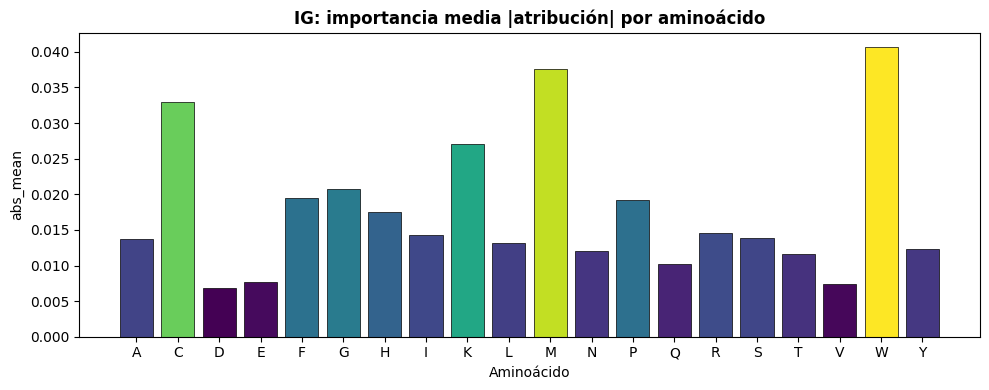

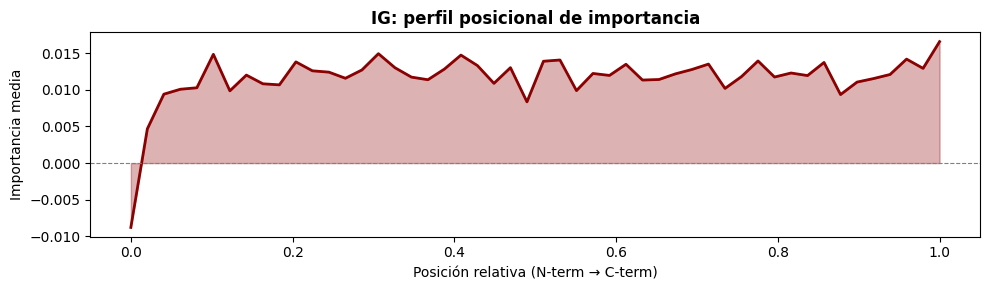

In [20]:
# ======= VISUALIZACIÓN: IMPORTANCIA SOBRE LA SECUENCIA DE AA =======

def plot_residue_importance_sequence(seq, importance, title="", ax=None, cmap_name="RdBu_r", save_path=None):
    """Colorea cada residuo de la cadena según su importancia (rojo=+AMP, azul=-AMP)."""
    importance = np.asarray(importance)
    vmax = np.abs(importance).max() or 1.0
    norm = Normalize(vmin=-vmax, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)
    if ax is None:
        fig, ax = plt.subplots(figsize=(max(8, len(seq) * 0.35), 2.0))
    else:
        fig = ax.figure
    for i, (aa, val) in enumerate(zip(seq, importance)):
        color = cmap(norm(val))
        ax.add_patch(mpatches.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor="white", linewidth=0.5))
        txt_color = "white" if abs(norm(val) - 0.5) > 0.3 else "black"
        ax.text(i + 0.5, 0.5, aa, ha="center", va="center", fontsize=11, fontweight="bold", color=txt_color)
    ax.set_xlim(0, len(seq)); ax.set_ylim(0, 1); ax.set_yticks([]); ax.set_xticks([])
    ax.set_title(title, fontsize=12, fontweight="bold")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.1, pad=0.3, label="Importancia")
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, ax

def aggregate_importance_by_aa(sequences, importances):
    """Agrega importancia (media y |media|) por tipo de aminoácido, a través de todas las secuencias."""
    records = [{"aa": aa, "importance": val}
               for seq, imp in zip(sequences, importances) for aa, val in zip(seq, imp)]
    df = pd.DataFrame(records)
    df = df[df["aa"].isin(AA_CANONICAL)]
    summary = df.groupby("aa")["importance"].agg(mean="mean", count="count").reindex(AA_CANONICAL)
    summary["abs_mean"] = df.groupby("aa")["importance"].apply(lambda x: x.abs().mean()).reindex(AA_CANONICAL)
    return summary.reset_index()

def plot_aa_importance_bar(summary_df, value_col="abs_mean", title=""):
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = plt.get_cmap("viridis")(Normalize()(summary_df[value_col].fillna(0).values))
    ax.bar(summary_df["aa"], summary_df[value_col], color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Aminoácido"); ax.set_ylabel(value_col); ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    return fig, ax

def aggregate_importance_by_position(sequences, importances, n_bins=N_BINS):
    """Perfil de importancia según posición relativa N-term → C-term (bineado)."""
    binned = np.zeros(n_bins); counts = np.zeros(n_bins)
    for seq, imp in zip(sequences, importances):
        L = len(seq)
        if L == 0: continue
        rel_pos = np.linspace(0, 1, L, endpoint=False)
        bin_idx = np.minimum((rel_pos * n_bins).astype(int), n_bins - 1)
        for b, val in zip(bin_idx, imp):
            binned[b] += val; counts[b] += 1
    counts[counts == 0] = 1
    return binned / counts

def plot_positional_importance(mean_by_bin, title=""):
    fig, ax = plt.subplots(figsize=(10, 3))
    x = np.linspace(0, 1, len(mean_by_bin))
    ax.plot(x, mean_by_bin, color="darkred", linewidth=2)
    ax.fill_between(x, 0, mean_by_bin, alpha=0.3, color="darkred")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Posición relativa (N-term → C-term)"); ax.set_ylabel("Importancia media")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    return fig, ax

# ---- Aplicado a resultados de IG ----
seqs_ig, imps_ig = [r["seq"] for r in ig_results], [r["importance"] for r in ig_results]
aa_summary_ig = aggregate_importance_by_aa(seqs_ig, imps_ig)
plot_aa_importance_bar(aa_summary_ig, "abs_mean", "IG: importancia media |atribución| por aminoácido")
pos_profile_ig = aggregate_importance_by_position(seqs_ig, imps_ig)
plot_positional_importance(pos_profile_ig, "IG: perfil posicional de importancia")


## 🧩 Función auxiliar para normalizar la salida de SHAP

In [21]:
def _as_1d_shap_array(shap_values, L):
    """
    Normaliza el retorno de KernelExplainer.shap_values(...) a un vector 1D
    de longitud L. Distintas versiones de `shap` devuelven ndarray (1, L),
    lista de un solo array, lista por clase, o un objeto shap.Explanation
    (API nueva) — aquí cubrimos los casos más comunes.
    """
    if hasattr(shap_values, "values"):          # shap.Explanation
        shap_values = shap_values.values

    if isinstance(shap_values, list):
        arrs = [np.asarray(v) for v in shap_values]
        candidates = [a for a in arrs if a.shape[-1] == L]
        if not candidates:
            raise ValueError(
                f"Ningún elemento de shap_values coincide con L={L}. "
                f"Formas encontradas: {[a.shape for a in arrs]}"
            )
        arr = candidates[-1]   # si hay varias "clases", la última suele ser la positiva (AMP)
    else:
        arr = np.asarray(shap_values)

    arr = arr.reshape(-1, L)[0] if arr.ndim > 1 else arr.reshape(L)
    return arr.astype(float)

## 🧠 SHAP global con KernelExplainer a nivel de residuo

Acuerdo global IG vs SHAP (por tipo de AA), Spearman rho=0.850, p=0.0000


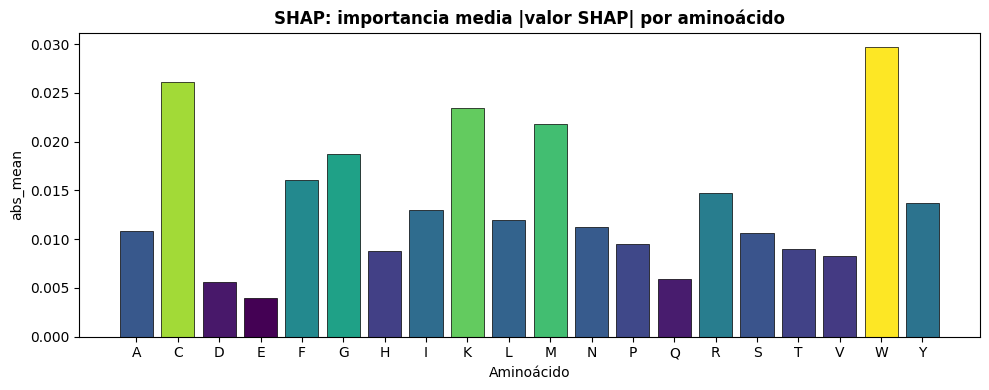

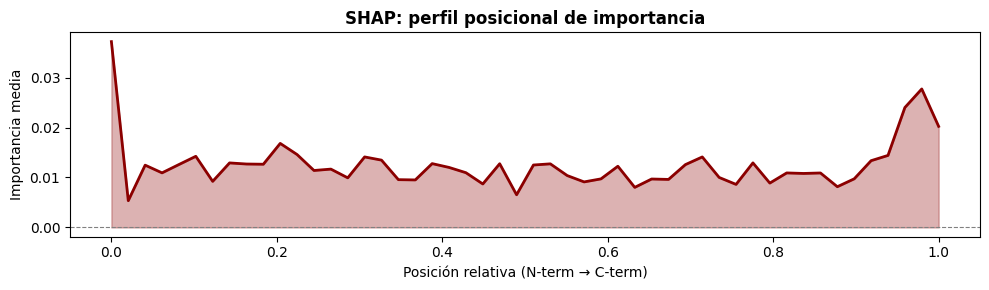

In [22]:
# ======= SHAP (GLOBAL, KernelExplainer a nivel de residuo) =======

class ResidueShapWrapper:
    def __init__(self, model, X_sample, Ont_sample, L_real):
        self.model = model
        self.L = L_real

        # Se recorta aquí por si X_sample/Ont_sample llegan con padding a L_max
        self.X_sample = X_sample[:L_real].to(DEVICE)
        self.Ont_sample = Ont_sample[:L_real].to(DEVICE)

        self.baseline_X = BASELINE_X.to(DEVICE)
        self.baseline_Ont = BASELINE_ONT.to(DEVICE)

    @torch.no_grad()
    def __call__(self, mask_batch: np.ndarray) -> np.ndarray:
        n = mask_batch.shape[0]

        m = torch.from_numpy(mask_batch).float().to(DEVICE).unsqueeze(-1)  # (n, L, 1)

        X_batch = self.X_sample.unsqueeze(0).expand(n, -1, -1).clone()
        Ont_batch = self.Ont_sample.unsqueeze(0).expand(n, -1, -1).clone()

        X_batch = m * X_batch + (1 - m) * self.baseline_X
        Ont_batch = m * Ont_batch + (1 - m) * self.baseline_Ont

        M_batch = torch.ones(n, self.L, device=DEVICE)

        return torch.sigmoid(
            self.model(X_batch, Ont_batch, M_batch)
        ).squeeze(-1).cpu().numpy()


def _build_shap_background(L, n_pool=N_SHAP_BG, k=SHAP_BG_SUMMARY_K):
    """
    Background para KernelSHAP a nivel de residuo.

    El background corresponde a "todos los residuos enmascarados",
    es decir, una máscara binaria de ceros.

    No se usa shap.kmeans porque el pool sería degenerado:
    todas las filas serían idénticas, y shap.kmeans puede fallar
    con el error:
        ValueError: # of weights must match data matrix!
    """
    return np.zeros((1, L), dtype=np.float32)


def _as_scalar_expected_value(expected_value):
    """
    Convierte expected_value a float simple, por si SHAP devuelve
    array/list en alguna versión.
    """
    arr = np.asarray(expected_value).reshape(-1)
    if arr.size == 0:
        return 0.0
    return float(arr[0])


def compute_shap_for_sample(model, X, Ont, seq, nsamples="auto"):
    
    L = len(seq)

    wrapper = ResidueShapWrapper(model, X, Ont, L)
    background = _build_shap_background(L)

    explainer = shap.KernelExplainer(wrapper, background)

    instance = np.ones((1, L), dtype=np.float32)

    shap_values = explainer.shap_values(
        instance,
        nsamples=nsamples,
        silent=True
    )

    sv = _as_1d_shap_array(shap_values, L)
    ev = _as_scalar_expected_value(explainer.expected_value)

    return sv, ev


def compute_shap_global(model, samples, nsamples=SHAP_NSAMPLES_GLOBAL, seed=SEED):
    np.random.seed(SEED)
    seqs, shap_list = [], []

    for item in samples:
        sv, _ = compute_shap_for_sample(
            model,
            item["X"],
            item["Ont"],
            item["seq"],
            nsamples=nsamples
        )

        seqs.append(item["seq"])
        shap_list.append(sv)

    return seqs, shap_list


# ---- Ejecución ----
shap_samples = build_sample_list(
    X_all, Ont_all, M_all, seqs_all, y_all, N_SHAP_EXPLAIN
)

shap_seqs, shap_values_list = compute_shap_global(
    model,
    shap_samples,
    nsamples=SHAP_NSAMPLES_GLOBAL
)

aa_summary_shap = aggregate_importance_by_aa(shap_seqs, shap_values_list)
plot_aa_importance_bar(
    aa_summary_shap,
    "abs_mean",
    "SHAP: importancia media |valor SHAP| por aminoácido"
)

pos_profile_shap = aggregate_importance_by_position(shap_seqs, shap_values_list)
plot_positional_importance(
    pos_profile_shap,
    "SHAP: perfil posicional de importancia"
)

rho_aa, p_aa = spearmanr(
    aa_summary_ig["abs_mean"],
    aa_summary_shap["abs_mean"]
)

print(f"Acuerdo global IG vs SHAP (por tipo de AA), Spearman rho={rho_aa:.3f}, p={p_aa:.4f}")

## 🧪 Caso de estudio LL-37: evaluación de predicción, IG y SHAP

LL-37 → índice en test set: 866 (ID esperado: test_pos_1720)
y_true = 1 (esperado 1, ya que el ID indica 'test_pos')
LL-37 — P(AMP) = 0.7902 | y_true = 1 | y_pred = 1
IG — delta de convergencia: 0.00654
SHAP — expected_value: 0.0404 | residual de completitud: 0.00000
Concordancia IG vs SHAP (Spearman ρ): 0.709 (p=0.0000)


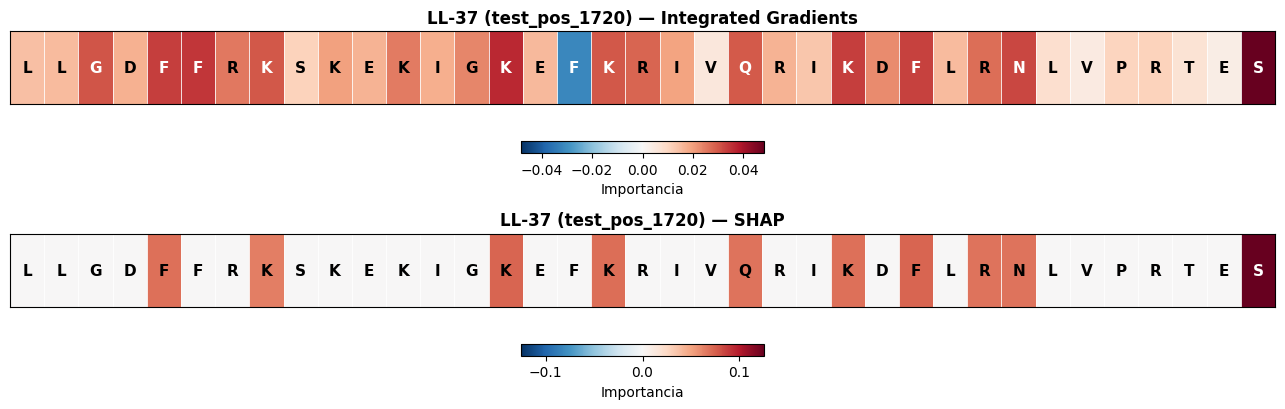

Saved: /kaggle/working/ig_shap_captum_LL37_test_pos_1720.html
KR-12 esperado: KRIVQRIKDFLR
IG — |importancia| media KR-12: 0.0228 | fuera: 0.0209 | Mann-Whitney U p=0.3190 (NO significativo a α=0.10)
SHAP — |importancia| media KR-12: 0.0291 | fuera: 0.0160 | Mann-Whitney U p=0.1029 (NO significativo a α=0.10)


In [23]:
# ============================================================
# CASO DE ESTUDIO: LL-37 (test_pos_1720)
# ============================================================

LL37_SEQ = "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES"

# --- 1. Localizar la muestra en el test set ---
matches = [i for i, s in enumerate(seqs_all) if s == LL37_SEQ]
if not matches:
    import difflib
    close = difflib.get_close_matches(LL37_SEQ, seqs_all, n=3, cutoff=0.9)
    raise ValueError(f"LL-37 no encontrada por coincidencia exacta. Candidatos cercanos: {close}")
if len(matches) > 1:
    print(f"⚠️ LL-37 aparece {len(matches)} veces: índices {matches}")

ll37_idx = matches[0]
print(f"LL-37 → índice en test set: {ll37_idx} (ID esperado: test_pos_1720)")

X_ll37, Ont_ll37, M_ll37, seq_ll37, y_ll37 = get_trimmed_sample(ll37_idx)
assert seq_ll37 == LL37_SEQ, "La secuencia recuperada no coincide con LL37_SEQ"
print(f"y_true = {y_ll37} (esperado 1, ya que el ID indica 'test_pos')")

# --- 2. Predicción del modelo ---
with torch.no_grad():
    prob_ll37 = torch.sigmoid(model(
        X_ll37.unsqueeze(0).to(DEVICE), Ont_ll37.unsqueeze(0).to(DEVICE), M_ll37.unsqueeze(0).to(DEVICE)
    )).item()
pred_class_ll37 = int(prob_ll37 >= THRESHOLD)
print(f"LL-37 — P(AMP) = {prob_ll37:.4f} | y_true = {y_ll37} | y_pred = {pred_class_ll37}")

# --- 3. Integrated Gradients (local) ---
ig_ll37, delta_ll37 = compute_ig_for_sample(model, X_ll37, Ont_ll37, M_ll37, seq_ll37)
print(f"IG — delta de convergencia: {delta_ll37:.5f}")

# --- 4. SHAP (local) ---
shap_ll37, shap_ev_ll37 = compute_shap_for_sample(
    model, X_ll37, Ont_ll37, seq_ll37, nsamples=SHAP_NSAMPLES_CASE_STUDY
)
shap_completeness_delta = prob_ll37 - (shap_ev_ll37 + sum(shap_ll37))
print(f"SHAP — expected_value: {shap_ev_ll37:.4f} | residual de completitud: {shap_completeness_delta:.5f}")

# --- 5. Concordancia entre métodos ---
rho, pval = spearmanr(ig_ll37, shap_ll37)
print(f"Concordancia IG vs SHAP (Spearman ρ): {rho:.3f} (p={pval:.4f})")

# --- 6. Visualización matplotlib (heatmap sobre la secuencia) ---
fig, axes = plt.subplots(2, 1, figsize=(max(8, len(seq_ll37) * 0.35), 4.2))
plot_residue_importance_sequence(seq_ll37, ig_ll37, title="LL-37 (test_pos_1720) — Integrated Gradients", ax=axes[0])
plot_residue_importance_sequence(seq_ll37, shap_ll37, title="LL-37 (test_pos_1720) — SHAP", ax=axes[1])
plt.tight_layout()
plt.savefig(XAI_DIR / "ll37_ig_shap_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# --- 7. Visualización HTML estilo Captum (word_attributions) ---
def build_vis_record(seq, scores, pred_prob, pred_class, true_class, convergence_score=0.0):
    scores = np.asarray(scores, dtype=float)
    max_abs = np.max(np.abs(scores)) + 1e-9
    scores_norm = (scores / max_abs).tolist()
    return captum_viz.VisualizationDataRecord(
        word_attributions=scores_norm,
        pred_prob=pred_prob,
        pred_class=str(pred_class),
        true_class=str(true_class),
        attr_class=str(pred_class),
        attr_score=sum(scores_norm),
        raw_input_ids=list(seq),
        convergence_score=convergence_score,
    )

records = [
    build_vis_record(seq_ll37, ig_ll37, prob_ll37, pred_class_ll37, y_ll37, convergence_score=delta_ll37),
    build_vis_record(seq_ll37, shap_ll37, prob_ll37, pred_class_ll37, y_ll37, convergence_score=shap_completeness_delta),
]
html = captum_viz.visualize_text(records)
html_path = XAI_DIR / "ig_shap_captum_LL37_test_pos_1720.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(html.data)
print(f"Saved: {html_path}")

# --- 8. Validación biológica: fragmento mínimo KR-12 (residuos 18-29, Wang, 2008) ---
from scipy.stats import mannwhitneyu

KR12_START, KR12_END = 18, 29
kr12_mask = np.zeros(len(seq_ll37), dtype=bool)
kr12_mask[KR12_START - 1:KR12_END] = True
print(f"KR-12 esperado: {seq_ll37[KR12_START - 1:KR12_END]}")

for name, imp in [("IG", ig_ll37), ("SHAP", shap_ll37)]:
    in_kr12 = np.abs(imp[kr12_mask])
    out_kr12 = np.abs(imp[~kr12_mask])
    u_stat, p_val = mannwhitneyu(in_kr12, out_kr12, alternative="greater")
    sig = "significativo" if p_val < 0.10 else "NO significativo"
    print(f"{name} — |importancia| media KR-12: {in_kr12.mean():.4f} | fuera: {out_kr12.mean():.4f} "
          f"| Mann-Whitney U p={p_val:.4f} ({sig} a α=0.10)")

## 🧪 Validación de KR-12 mediante Mann–Whitney comparando su importancia con los residuos externos, excluyendo los extremos de la secuencia.

In [24]:
interior_mask = np.ones(len(seq_ll37), dtype=bool)
interior_mask[[0, -1]] = False  # excluye primer y último residuo

for name, imp in [("IG", ig_ll37), ("SHAP", shap_ll37)]:
    mask_out = (~kr12_mask) & interior_mask   # "fuera de KR-12" SIN los extremos
    in_kr12 = np.abs(imp[kr12_mask])
    out_no_edge = np.abs(imp[mask_out])
    u, p = mannwhitneyu(in_kr12, out_no_edge, alternative="greater")
    sig = "significativo" if p < 0.10 else "NO significativo"
    print(f"{name} (sin extremos) — KR-12: {in_kr12.mean():.4f} | fuera: {out_no_edge.mean():.4f} | p={p:.4f}  ({sig} a α=0.10)")

IG (sin extremos) — KR-12: 0.0228 | fuera: 0.0200 | p=0.2832  (NO significativo a α=0.10)
SHAP (sin extremos) — KR-12: 0.0291 | fuera: 0.0119 | p=0.0620  (significativo a α=0.10)


## 🏁 Conclusión: interpretabilidad del modelo BiLSTM_Small

El pipeline de explicabilidad permite identificar, a nivel de residuo, las posiciones que más contribuyen a la predicción del `BiLSTM_Small` (Mean Pooling + AAontology), combinando la dinámica interna del LSTM con explicaciones post‑hoc.

### Resultados destacados

| Técnica | Tipo | Detalle |
|---|---|---|
| Hook sobre `model.lstm` | Importancia interna | Norma‑L2 de los estados ocultos bidireccionales enmascarados |
| Integrated Gradients | Post‑hoc | Línea base nula, 100 pasos de integración |
| KernelSHAP | Post‑hoc | Enmascaramiento de residuos, background con máscara cero |
| Validación biológica | Caso de estudio | Péptido LL‑37 |

### Análisis

- **Importancia interna:** la norma‑L2 de los estados ocultos enmascarados revela qué posiciones activan con mayor intensidad la dinámica bidireccional del LSTM, sin depender de un `GatedPooler`.
- **Robustez post‑hoc:** la coincidencia entre Integrated Gradients y KernelSHAP refuerza la fiabilidad de los residuos destacados, al ser métodos con fundamentos distintos (atribución por integración vs. teoría de juegos).
- **Validación biológica:** el estudio de caso sobre LL‑37 confirma que el modelo prioriza la región funcional esperada, aportando plausibilidad biológica a las predicciones.

**Estado final:** el notebook entrega mapas de importancia a nivel de residuo, comparativas entre métodos y una validación biológica sobre LL‑37, cerrando el ciclo de interpretabilidad de la mejor estrategia del proyecto.